# **Benchmarking Models for Temperature Prediction with MLFlow**

Author: **Rai Peladas** <br>
Date Created: **January 27, 2026** <br>
Date Modified: **March 5, 2026** <br>
Version: **4** <br>

## **Problem Statement**

Climate change is increasing weather variability making temperature prediction even more critical for decision-making in productivity sectors within cities such as energy, transport, and disaster risk management. As climate patterns shift, traditional assumptions about weather stability no longer hold, creating uncertainty that affects planning and operations.

However, temperature is influenced by multiple interacting atmospheric factors, making prediction a complex modeling problem. To address this, different regression models must be systematically tested and compared to determine which approach best captures temperature behavior. Using tools such as scikit-learn for modeling and MLflow for experiment tracking enables structured, reproducible evaluation of these models.

The core problem is to develop and compare regression models that predict mean temperature accurately, while implementing a reliable experimentation workflow to support model improvement and transparency. 

## **Data Preparation**

The [London Weather Data](https://www.kaggle.com/datasets/emmanuelfwerr/london-weather-data) dataset from Kaggle contains historical daily weather observations for London. 

The dataset includes the following key features: 

| Column | Data Type | Description |
|---|---|---|
| `date` | int | recorded date of measurement |
| `cloud_cover` | float | cloud cover measurement in oktas |
| `sunshine` | float | sunshine measurement in hours (hrs) |
| `global_radiation` | float | irradiance measurement in Watt per square meter (W/m2) |
| `max_temp` | float | maximum temperature recorded in degrees Celsius (°C) |
| `mean_temp` | float | mean temperature in degrees Celsius (°C) |
| `min_temp` | float | minimum temperature recorded in degrees Celsius (°C) |
| `precipitation` | float | precipitation measurement in millimeters (mm) |
| `pressure` | float | pressure measurement in Pascals (Pa) |
| `snow_depth` | float | snow depth measurement in centimeters (cm) |

In [23]:
# Import libraries 

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [24]:
# Read data
df = pd.read_csv("weather_data.csv")

In [25]:
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


In [27]:
df.describe()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,1.534100e+04,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000,15335.000000,15337.000000,13900.000000
mean,1.999567e+07,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867,1.668634,101536.605594,0.037986
std,1.212176e+05,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756,3.738540,1049.722604,0.545633
min,1.979010e+07,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,1.989070e+07,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,2.000010e+07,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,2.010070e+07,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,2.020123e+07,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


In [28]:
df.isnull().sum()

date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64

In [29]:
df.columns.to_list()

['date',
 'cloud_cover',
 'sunshine',
 'global_radiation',
 'max_temp',
 'mean_temp',
 'min_temp',
 'precipitation',
 'pressure',
 'snow_depth']

In [30]:
# Correct date column to datetime format and extract year and month 
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [31]:
# Drop null values in mean_temp column 
df = df.dropna(subset=["mean_temp"], axis=0, inplace=False)

In [32]:
# Retain relevant columns for modeling 
relevant_columns = ["date", "month", "year", "cloud_cover", "sunshine", "precipitation", "pressure", "global_radiation", "mean_temp"]
df = df[relevant_columns]

In [33]:
# Details on updated dataset 
df.head()

,date,month,year,cloud_cover,sunshine,precipitation,pressure,global_radiation,mean_temp
0,1979-01-01,1,1979,2.0,7.0,0.4,101900.0,52.0,-4.1
1,1979-01-02,1,1979,6.0,1.7,0.0,102530.0,27.0,-2.6
2,1979-01-03,1,1979,5.0,0.0,0.0,102050.0,13.0,-2.8
3,1979-01-04,1,1979,8.0,0.0,0.0,100840.0,13.0,-2.6
4,1979-01-05,1,1979,6.0,2.0,0.0,102250.0,29.0,-0.8


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15305 entries, 0 to 15340
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              15305 non-null  datetime64[ns]
 1   month             15305 non-null  int32         
 2   year              15305 non-null  int32         
 3   cloud_cover       15286 non-null  float64       
 4   sunshine          15305 non-null  float64       
 5   precipitation     15303 non-null  float64       
 6   pressure          15301 non-null  float64       
 7   global_radiation  15286 non-null  float64       
 8   mean_temp         15305 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int32(2)
memory usage: 1.1 MB


In [35]:
df.describe()

,date,month,year,cloud_cover,sunshine,precipitation,pressure,global_radiation,mean_temp
count,15305,15305.000000,15305.000000,15286.000000,15305.000000,15303.000000,15301.000000,15286.000000,15305.000000
mean,1999-12-23 09:49:49.846455424,6.523358,1999.476772,5.267107,4.352382,1.669352,101536.896281,118.758864,11.475511
min,1979-01-01 00:00:00,1.000000,1979.000000,0.000000,0.000000,0.000000,95960.000000,8.000000,-7.600000
25%,1989-06-23 00:00:00,4.000000,1989.000000,4.000000,0.500000,0.000000,100920.000000,41.000000,7.000000
50%,1999-12-14 00:00:00,7.000000,1999.000000,6.000000,3.500000,0.000000,101620.000000,95.000000,11.400000
75%,2010-07-04 00:00:00,10.000000,2010.000000,7.000000,7.200000,1.600000,102240.000000,186.000000,16.000000
max,2020-12-31 00:00:00,12.000000,2020.000000,9.000000,16.000000,61.800000,104820.000000,402.000000,29.000000
std,NaN,3.448807,12.123509,2.070059,4.028954,3.739994,1049.725819,88.890133,5.729709


In [36]:
df.isnull().sum()

date                 0
month                0
year                 0
cloud_cover         19
sunshine             0
precipitation        2
pressure             4
global_radiation    19
mean_temp            0
dtype: int64

## **Exploratory Data Analysis**

<Figure size 1200x800 with 0 Axes>

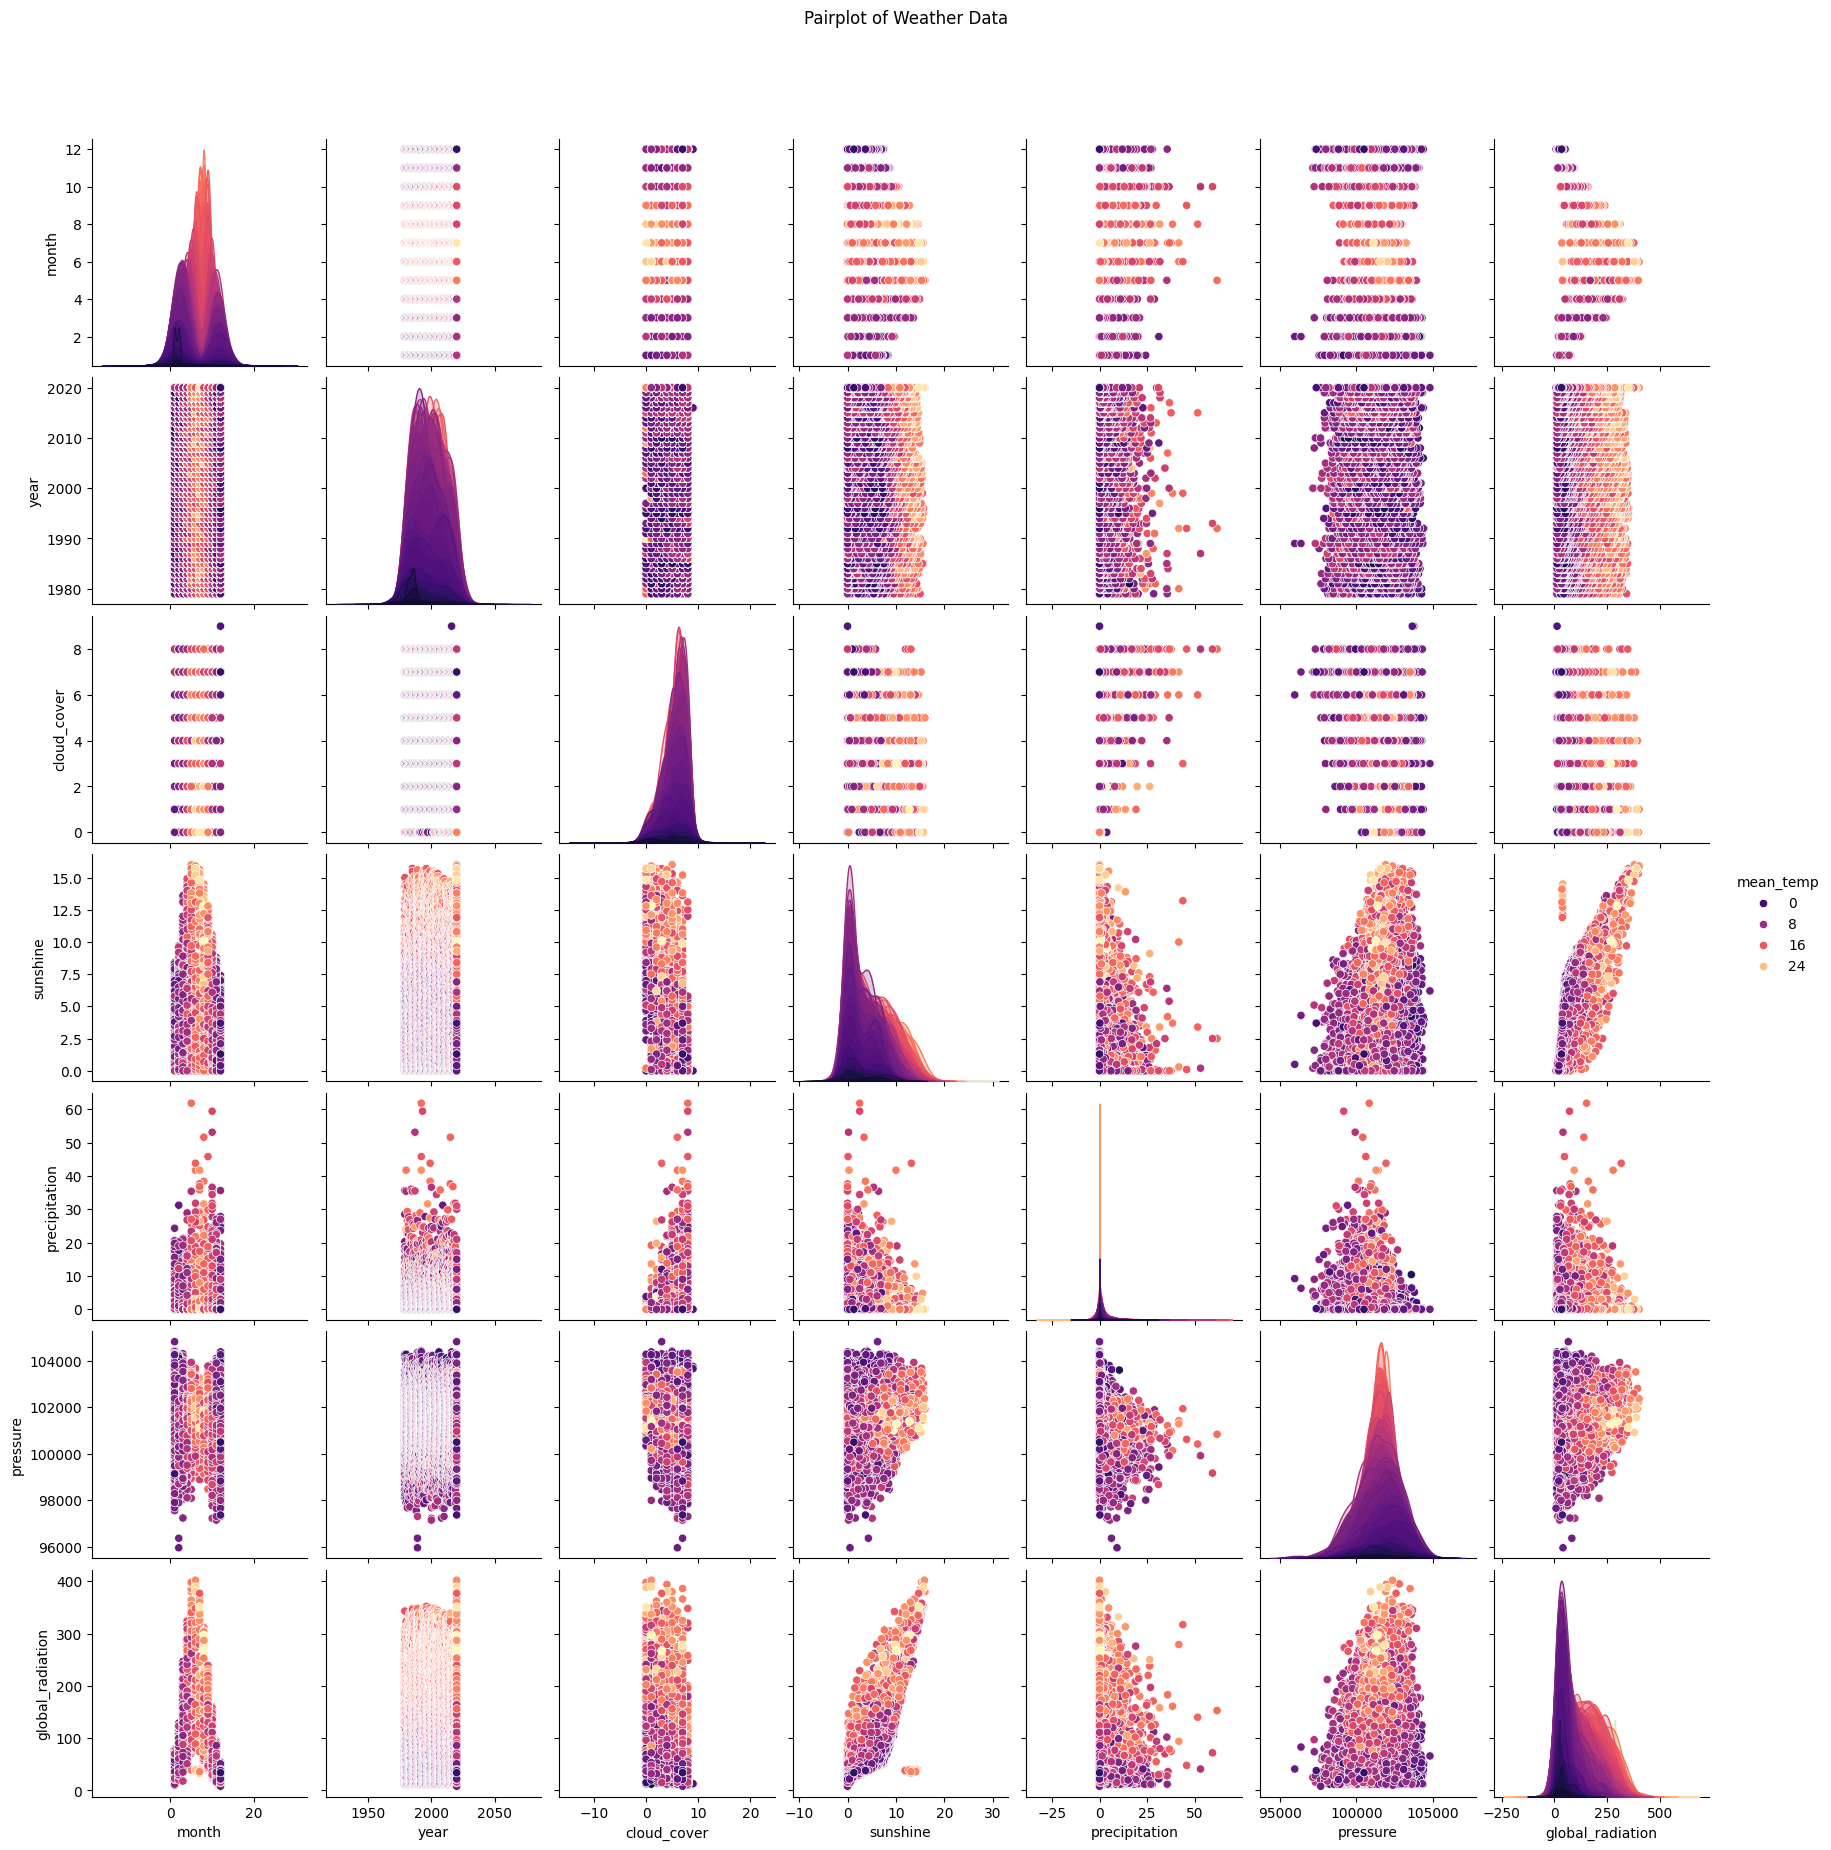

In [37]:
plt.figure(figsize=(12, 8))
sns.pairplot(df, hue="mean_temp", palette="magma")
plt.suptitle("Pairplot of Weather Data", y=1.06)
plt.show()

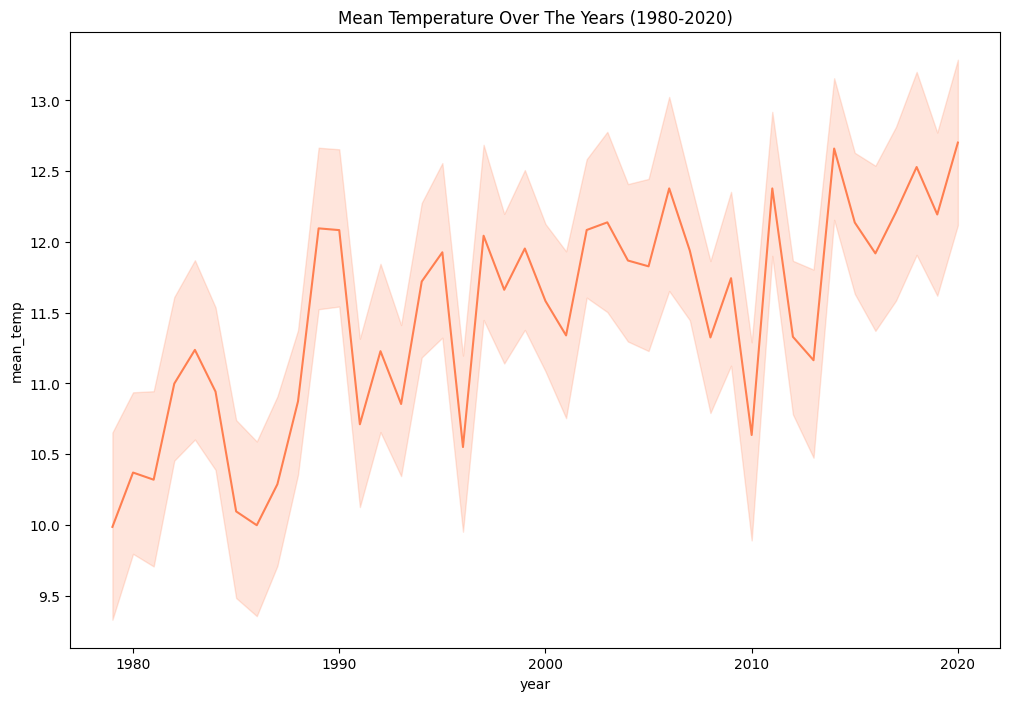

In [45]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=df, x="year", y="mean_temp", color="coral")
plt.title("Mean Temperature Over The Years (1980-2020)")
plt.show()

It can be observed that the average temperature is increasing over the years. 

Text(0.5, 1.0, 'Correlation Heatmap between Features')

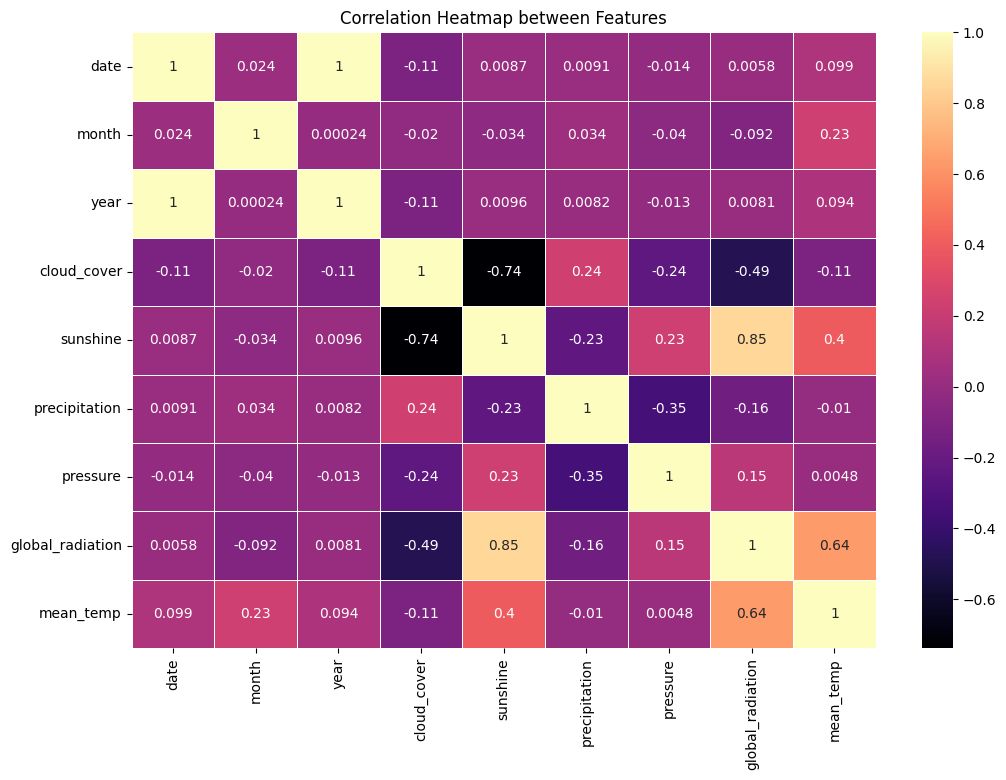

In [53]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="magma", linewidths=0.5)
plt.title("Correlation Heatmap between Features")

The following relationships can be inferred given the correlation between variables: 
- `global_radiation` has the strongest positive correlation with the target variable `mean_temp` with r = 0.64 suggesting a moderately strong linear association. 
- `sunshine` also shows a positive correlation with the target variable `mean_temp` though weaker at r = 0.40.
- `pressure` and `precipitation` show near-zero correlation with `mean_temp`, indicating little linear association with the target variable. 
- `global_radiation` and `sunshine` also have a strong positive relationship with each other being r = 0.85 which may indicate multicollinearity. 

Despite the limited number of strong pairwise correlations with the target variable, all weather-related features will be retained for initial modeling. This is because weather systems involve complex interactions with the multiple factors, and variables with weak individual linear correlations may still contribute to useful predictions when considered together. 

## **Data Preprocessing**

In [55]:
# Split training and testing data
X = df.drop(["date", "year", "mean_temp"], axis=1).values
y = df["mean_temp"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
# Initialize pipeline for imputation and scaling 
steps = [
    ("imputer", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
]

# Setup pipeline 
preprocess_pipeline = Pipeline(steps)

# Apply preprocessing pipeline to data
X_train_scaled = preprocess_pipeline.fit_transform(X_train)
X_test_scaled = preprocess_pipeline.transform(X_test)

## **Model Development**

In [61]:
# Setup MLFlow tracking 
experiment_name = "Predicting Mean Temperature with Regression Models v1"
mlflow.create_experiment(experiment_name)
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='/home/rai/predict-temp/Benchmarking-Models-For-Temperature-Prediction-with-MLFlow/mlruns/2', creation_time=1772764878988, experiment_id='2', last_update_time=1772764878988, lifecycle_stage='active', name='Predicting Mean Temperature with Regression Models v1', tags={}, workspace='default'>

In [62]:
# Linear regression models 
with mlflow.start_run(run_name="LinearRegression"):
    lr = LinearRegression()

    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    rmse_lr = np.sqrt(MSE(y_test, y_pred_lr))

    mlflow.log_metric("rmse", rmse_lr)

In [63]:
# Ridge regression
for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0]:
    with mlflow.start_run(run_name=f"Ridge_Alpha_{alpha}"):
        ridge = Ridge(alpha=alpha)

        ridge.fit(X_train_scaled, y_train)
        y_pred_ridge = ridge.predict(X_test_scaled)
        rmse_ridge = np.sqrt(MSE(y_test, y_pred_ridge))

        mlflow.log_metric("rmse", rmse_ridge)
        mlflow.log_param("ridge_alpha", alpha)

In [64]:
# Lasso regression
for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0]:
    with mlflow.start_run(run_name=f"Lasso_Alpha_{alpha}"):
        lasso = Lasso(alpha=alpha)

        lasso.fit(X_train_scaled, y_train)
        y_pred_lasso = lasso.predict(X_test_scaled)
        rmse_lasso = np.sqrt(MSE(y_test, y_pred_lasso))

        mlflow.log_metric("rmse", rmse_lasso)
        mlflow.log_param("lasso_alpha", alpha)

In [65]:
# Decision tree
for depth in [3, 5, 7, 10, None]:
    with mlflow.start_run(run_name=f"DecisionTree_MaxDepth_{depth}"):
        dt = DecisionTreeRegressor(max_depth=depth)

        dt.fit(X_train_scaled, y_train)
        y_pred_dt = dt.predict(X_test_scaled)
        rmse_dt = np.sqrt(MSE(y_test, y_pred_dt))

        mlflow.log_metric("rmse", rmse_dt)
        mlflow.log_param("dt_max_depth", depth)

In [66]:
# Random forest 
for idx, n_estimator in enumerate([i for i in range(10, 100 + 1, 10)]):
    with mlflow.start_run(run_name=f"RandomForest_nEstimators_{n_estimator}"):
        rf = RandomForestRegressor(n_estimators=n_estimator)

        rf.fit(X_train_scaled, y_train)
        y_pred_rf = rf.predict(X_test_scaled)
        rmse_rf = np.sqrt(MSE(y_test, y_pred_rf))

        mlflow.log_metric("rmse", rmse_rf)
        mlflow.log_param("rf_n_estimators", n_estimator)

## **Model Evaluation**

In [67]:
# Search logged results 

mlflow.search_runs()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.rmse,params.rf_n_estimators,params.dt_max_depth,params.lasso_alpha,params.ridge_alpha,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.source.name
0,b49e8d2ad1e04a5d8af8286cefe7540e,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:38.238000+00:00,2026-03-06 02:41:41.160000+00:00,2.883691,100,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_100,notebook.ipynb
1,67eb76c2ca4548a187d1ff183623f54e,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:35.668000+00:00,2026-03-06 02:41:38.218000+00:00,2.876247,90,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_90,notebook.ipynb
2,268fb89d028240579606a3077603fb60,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:33.334000+00:00,2026-03-06 02:41:35.648000+00:00,2.885732,80,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_80,notebook.ipynb
3,d58ca09de11d4808badc2a74237f2024,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:31.302000+00:00,2026-03-06 02:41:33.316000+00:00,2.891671,70,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_70,notebook.ipynb
4,afa32c01c3bd429187c03c4338d300db,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:29.555000+00:00,2026-03-06 02:41:31.277000+00:00,2.895449,60,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_60,notebook.ipynb
5,9fcd18144e4e4c7bb80a33eb8d43296e,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:28.098000+00:00,2026-03-06 02:41:29.523000+00:00,2.899082,50,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_50,notebook.ipynb
6,e581a46a42e4453290b1214c29df839f,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:26.930000+00:00,2026-03-06 02:41:28.076000+00:00,2.902872,40,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_40,notebook.ipynb
7,90369ace476a4eb6bd3ee5aba36d20b9,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:26.040000+00:00,2026-03-06 02:41:26.904000+00:00,2.912666,30,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_30,notebook.ipynb
8,01698dd68cc54c3aa841baa3b1a03ff1,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:25.395000+00:00,2026-03-06 02:41:26.018000+00:00,2.925832,20,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_20,notebook.ipynb
9,11337f5ac481422fa8561d9d1fec5cba,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:25.007000+00:00,2026-03-06 02:41:25.374000+00:00,3.004427,10,None,None,None,rai,NOTEBOOK,RandomForest_nEstimators_10,notebook.ipynb


In [68]:
rmse_filter = "metrics.rmse <= 3"
experiment_results = mlflow.search_runs(
    experiment_names=[experiment_name],
    filter_string=rmse_filter,
    order_by=["metrics.rmse DESC"],
)
experiment_results

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.rmse,params.dt_max_depth,params.rf_n_estimators,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.source.name
0,d901bde0fd6d4637b23730a86bc53930,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:24.003000+00:00,2026-03-06 02:41:24.122000+00:00,2.969909,5,None,rai,NOTEBOOK,DecisionTree_MaxDepth_5,notebook.ipynb
1,01698dd68cc54c3aa841baa3b1a03ff1,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:25.395000+00:00,2026-03-06 02:41:26.018000+00:00,2.925832,None,20,rai,NOTEBOOK,RandomForest_nEstimators_20,notebook.ipynb
2,90369ace476a4eb6bd3ee5aba36d20b9,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:26.040000+00:00,2026-03-06 02:41:26.904000+00:00,2.912666,None,30,rai,NOTEBOOK,RandomForest_nEstimators_30,notebook.ipynb
3,e581a46a42e4453290b1214c29df839f,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:26.930000+00:00,2026-03-06 02:41:28.076000+00:00,2.902872,None,40,rai,NOTEBOOK,RandomForest_nEstimators_40,notebook.ipynb
4,9fcd18144e4e4c7bb80a33eb8d43296e,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:28.098000+00:00,2026-03-06 02:41:29.523000+00:00,2.899082,None,50,rai,NOTEBOOK,RandomForest_nEstimators_50,notebook.ipynb
5,afa32c01c3bd429187c03c4338d300db,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:29.555000+00:00,2026-03-06 02:41:31.277000+00:00,2.895449,None,60,rai,NOTEBOOK,RandomForest_nEstimators_60,notebook.ipynb
6,d58ca09de11d4808badc2a74237f2024,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:31.302000+00:00,2026-03-06 02:41:33.316000+00:00,2.891671,None,70,rai,NOTEBOOK,RandomForest_nEstimators_70,notebook.ipynb
7,268fb89d028240579606a3077603fb60,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:33.334000+00:00,2026-03-06 02:41:35.648000+00:00,2.885732,None,80,rai,NOTEBOOK,RandomForest_nEstimators_80,notebook.ipynb
8,11ee28b0cf0548c1af546741489db1e6,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:24.149000+00:00,2026-03-06 02:41:24.271000+00:00,2.885587,7,None,rai,NOTEBOOK,DecisionTree_MaxDepth_7,notebook.ipynb
9,b49e8d2ad1e04a5d8af8286cefe7540e,2,FINISHED,/home/rai/predict-temp/Benchmarking-Models-For...,2026-03-06 02:41:38.238000+00:00,2026-03-06 02:41:41.160000+00:00,2.883691,None,100,rai,NOTEBOOK,RandomForest_nEstimators_100,notebook.ipynb


## **Conclusion**